<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/PLN/preprocesamientoYNormalizacionMCHD255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install unidecode spacy wordcloud
# !python -m spacy download es_core_news_sm

                                                                                   tuit                                                                      tuit_corregido
      Excelente iniciativa de el uso de energías renovables se expanda 🌎 #MedioAmbiente      excelente iniciativa de el uso de energias renovables se expanda medioambiente
         Inspirador que la contaminación plástica afecte los océanos ☀️ #Sostenibilidad          inspirador que la contaminacion plastica afecte los oceanos sostenibilidad
                      Datos muestran que los niveles de CO2 disminuyan 🌎 #MedioAmbiente                      datos muestran que los niveles de co2 disminuyan medioambiente
            Indignante que las temperaturas globales sigan aumentando ⚠️ #EcoConciencia             indignante que las temperaturas globales sigan aumentando ecoconciencia
                             Inspirador que la deforestación continúe 🌊 #Sostenibilidad                             inspirador que la defore

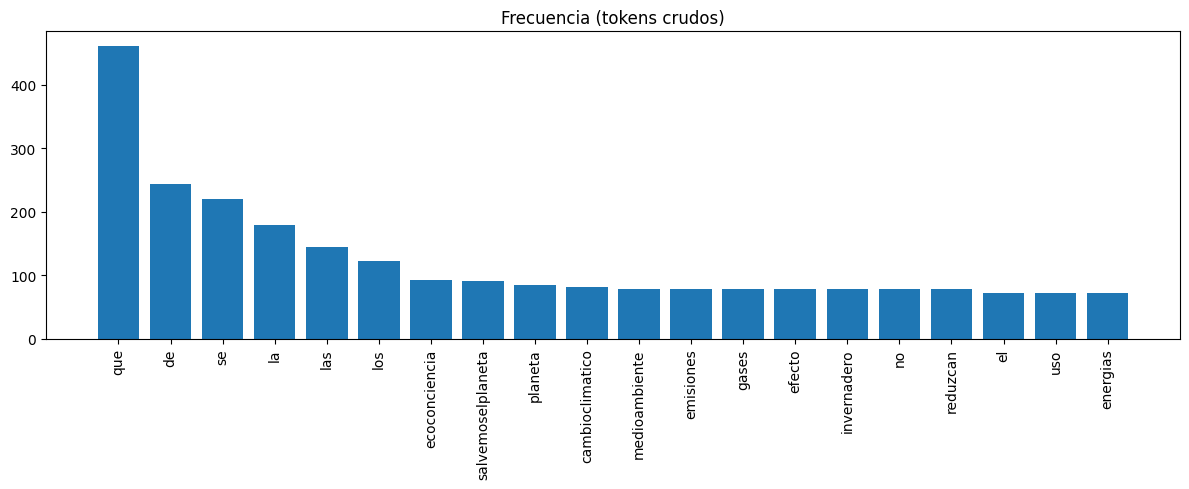

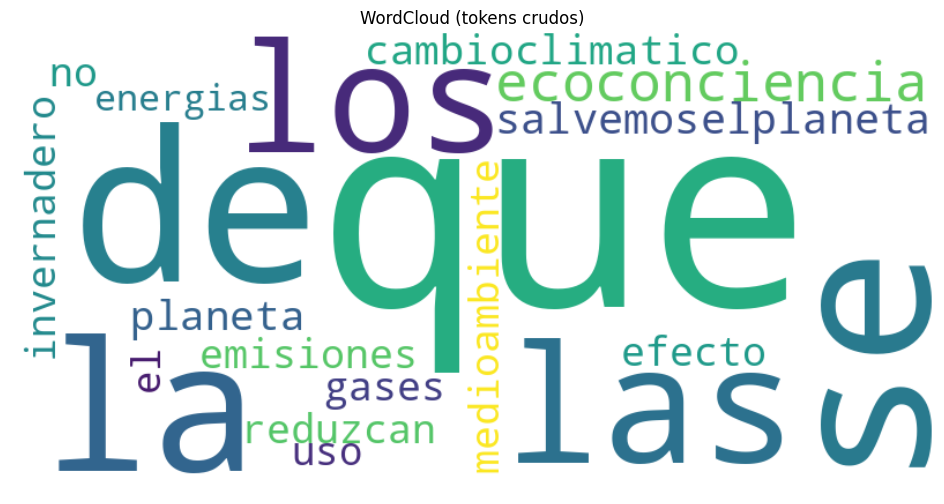


Lemas:
 ['excelente', 'iniciativa', 'de', 'el', 'uso', 'de', 'energia', 'renovable', 'el', 'expandar', 'medioambiente', 'inspirador', 'que', 'el', 'contaminacion', 'plastico', 'afectar', 'el', 'oceano', 'sostenibilidad', 'dato', 'mostrar', 'que', 'el', 'nivel', 'de', 'co2', 'disminuir', 'medioambiente', 'indignante', 'que', 'el', 'temperatura', 'global', 'seguir', 'aumentar', 'ecoconciencia', 'inspirador', 'que', 'el', 'deforestacion', 'continue', 'sostenibilidad', 'investigacion', 'revelar', 'que', 'el', 'deforestacion', 'continue', 'planeta']


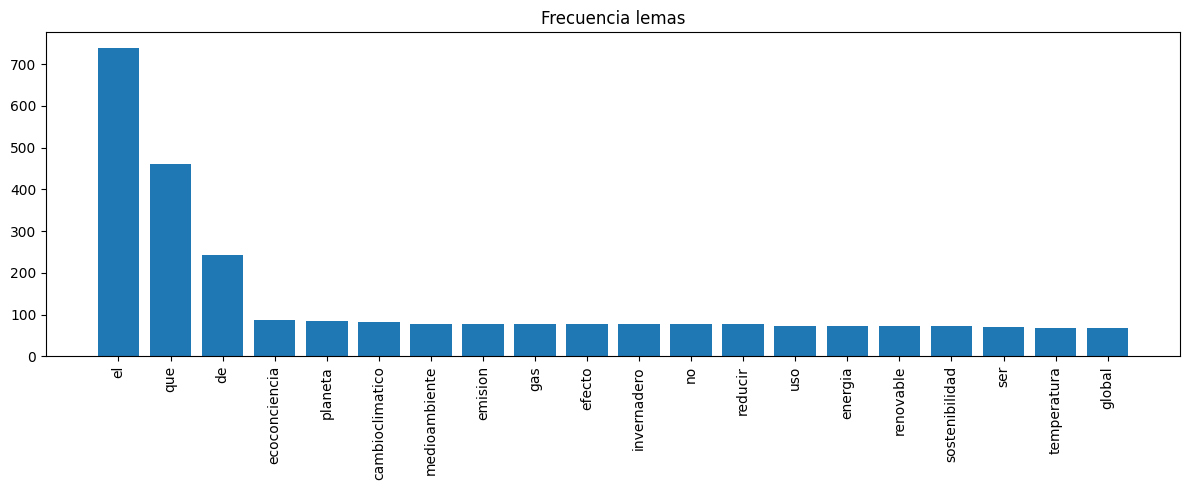

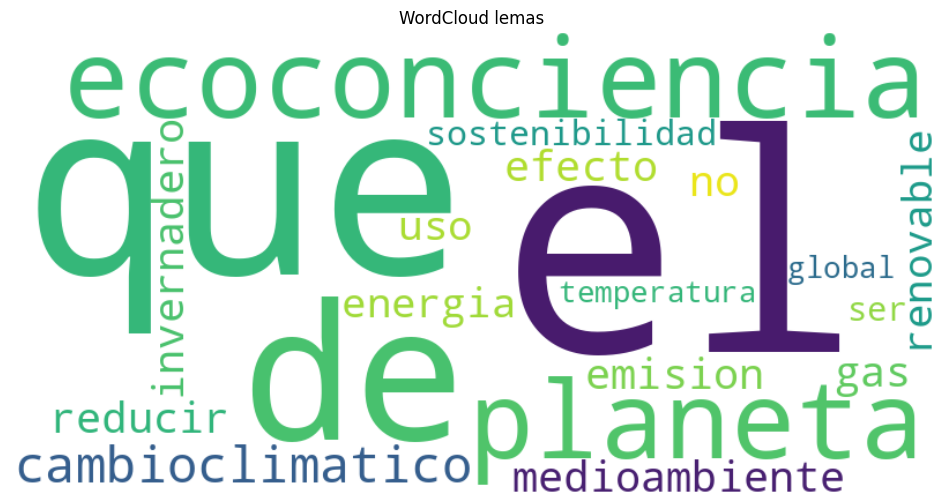


Lemas sin stopwords:
 ['excelente', 'iniciativa', 'energia', 'renovable', 'expandar', 'medioambiente', 'inspirador', 'contaminacion', 'plastico', 'afectar', 'oceano', 'sostenibilidad', 'dato', 'mostrar', 'nivel', 'co2', 'disminuir', 'medioambiente', 'indignante', 'temperatura', 'global', 'seguir', 'aumentar', 'ecoconciencia', 'inspirador', 'deforestacion', 'continue', 'sostenibilidad', 'investigacion', 'revelar', 'deforestacion', 'continue', 'planeta', 'alegrar', 'temperatura', 'global', 'seguir', 'aumentar', 'ecoconciencia', 'inaceptable', 'temperatura', 'global', 'seguir', 'aumentar', 'cambioclimatico', 'dato', 'mostrar', 'nivel', 'co2', 'disminuyar']


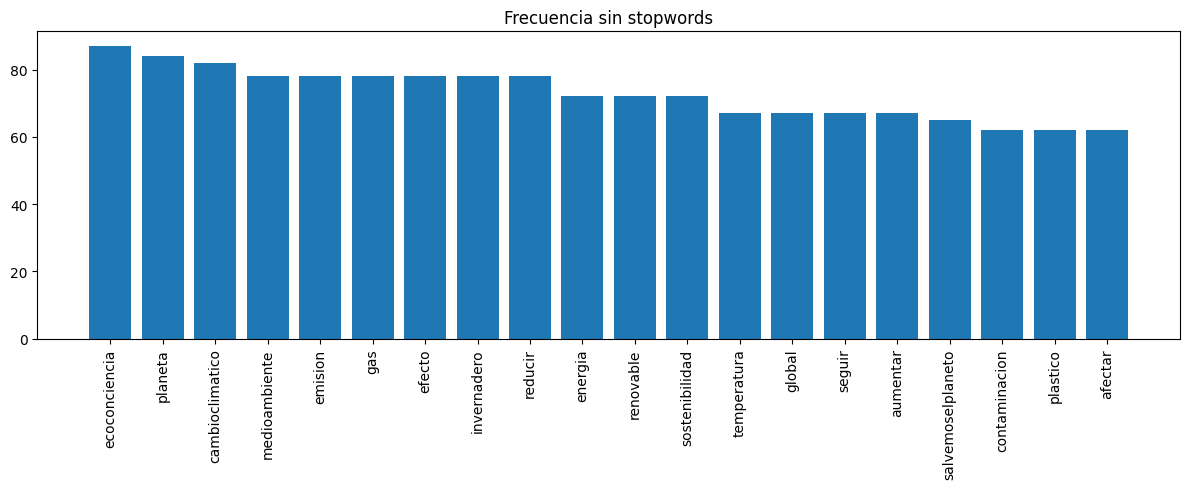

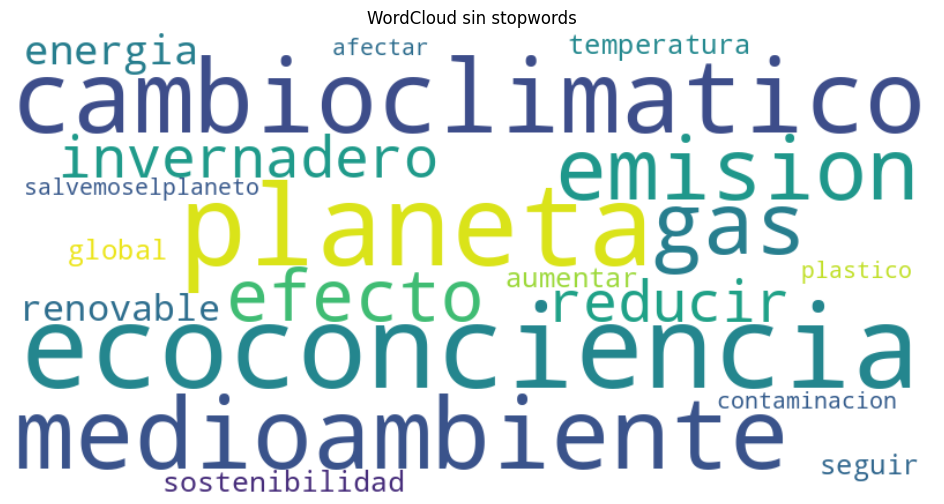

In [45]:
import re
import pandas as pd
from unidecode import unidecode
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import textwrap
from spellchecker import SpellChecker

# Cargar idioma español para el spellchecker
spell = SpellChecker(language='es')

# Cargar mopdelo en español
nlp = spacy.load("es_core_news_sm")

# Leer dataset
def leer_dataset(ruta):
  df = pd.read_csv(ruta)
  return df

def limpiar_texto(texto):
  # Eliminar caracteres especiales
  texto = texto.lower() # Convertir a minúsculas
  texto = unidecode(texto) # Eliminar acentos
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto) # Eliminar URL
  texto = re.sub(r'[\w\._%+-]+@[\w.-]+\.[A-Za-z]{2,}', '', texto) # Eliminar email
  texto = re.sub(r'(?<!\w)@\w+', '', texto) # Eliminar menciones
  texto = re.sub(r'(?<!\w)#(\w+)', r'\1', texto)  # Reemplaza #hashtag por hashtag
  texto = re.sub(r'[^\w\s]', '', texto) # Eliminar puntuación
  texto = re.sub(r'([aieou])\1+', r'\1', texto) # Eliminar vocales repetidas
  texto = re.sub(r'([bcdfghjklmnpqrstvwxyz])\1{2,}', r'\1', texto) # Eliminar consonantes repetidas (excepto www)
  texto = re.sub(r'\s+', ' ', texto).strip() # Eliminar espacios
  return texto

# Graficar
def graficar(tokens, titulo, top=20):
  freq = Counter(tokens).most_common(top)
  if not freq: return
  plt.figure(figsize=(12, 5))
  palabras, valores = zip(*freq) # Separa las palabras y los conteos en dos listas distintas para graficar
  plt.bar(palabras, valores)
  plt.title(titulo)
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

# WordCloud
def crear_wordcloud(tokens, titulo):
  if not tokens: return
  freq = dict(Counter(tokens).most_common(20)) # Calculo las 20 palabras más frecuentes manualmente
  wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)
  plt.figure(figsize=(14, 6))
  plt.imshow(wc, interpolation="bilinear")
  plt.axis("off")
  plt.title(titulo)
  plt.show()

# Tokenizar y visualización
def tokenizar(texto):
  tokens = [t.text for t in nlp(texto) if not t.is_space and not t.is_punct]
  print('\nTokens:\n', tokens[:50])
  graficar(tokens, "Frecuencia (tokens crudos)")
  crear_wordcloud(tokens, "WordCloud (tokens crudos)")
  return tokens

# Lematizar y visualizar
def lematizar(tokens):
  lemas = [unidecode(t.lemma_.lower()) for t in nlp(' '.join(tokens))] # Aplica lematización y normaliza con unidecode para quitar "él" y "emisión"
  print('\nLemas:\n', lemas[:50])
  graficar(lemas, "Frecuencia lemas")
  crear_wordcloud(lemas, "WordCloud lemas")
  return lemas

# Eliminar stopwords y visualizar
def quitar_stopwords(lemas):
  stop = set(unidecode(w.lower()) for w in nlp.Defaults.stop_words)
  limpios = [l for l in lemas if unidecode(l) not in stop and l.strip()]
  print('\nLemas sin stopwords:\n', limpios[:50])
  graficar(limpios, "Frecuencia sin stopwords")
  crear_wordcloud(limpios, "WordCloud sin stopwords")
  return limpios

# Ejecutar
if __name__ == "__main__":
  ruta = "/content/drive/MyDrive/ClassFiles/PLN/tuits_cambio_climatico.csv"
  df = leer_dataset(ruta)
  df['tuit_corregido'] = df['tuit'].astype(str).apply(limpiar_texto)
  texto = df['tuit_corregido'].astype(str).str.cat(sep=' ') # separamos por espacio
  print(df.head(20).to_string(index=False))
  tokens = tokenizar(texto)
  lemas = lematizar(tokens)
  limpios = quitar_stopwords(lemas)